# Example of creating custom dataset

See [docs](https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html#data-handling-of-graphs)

In [1]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

2.9.0+cu128


## Example of basic Dataset

In [2]:
from torch_geometric.data import Data

edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)
x = torch.tensor([[-1], [0], [1]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index)
data

C:\Users\jackd\source\colmap-experiments\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data(x=[3, 1], edge_index=[2, 4])

# Example of colmap dataset as graph

In [3]:
from pycolmap import Reconstruction

import utils.vis.plot_colmap

%load_ext autoreload
%autoreload 2

import pycolmap
import pathlib

model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')

# Load the reconstruction
reconstruction = pycolmap.Reconstruction(model_path)

# Print basic info about the reconstruction
print(f"Number of registered images: {len(reconstruction.images)}")
print(f"Number of 3D points: {len(reconstruction.points3D)}")

Number of registered images: 69
Number of 3D points: 6672


In [4]:
list(reconstruction.images.values())[0]

Image(image_id=57, camera=Camera(camera_id=1), name="r_57.png", has_pose=1, triangulated=677/3683)

## Load nodes as each image with attributes of image position (x, y, z)

In [5]:
import utils.subset

# Create node data. In this case, we will use image positions as our input features for each node.
image_centers = [image.projection_center() for image in reconstruction.images.values()]
# Store as tensor
x = torch.tensor(image_centers, dtype=torch.float)

# Create edge information. No edge features for now.
image_ids = [img.image_id for img in reconstruction.images.values()]
id_to_idx = {image_id: idx for idx, image_id in enumerate(image_ids)}

src, dst = [], []
for src_id in image_ids:
    for dst_id in utils.subset.get_covisible_image_ids(reconstruction, src_id):
        if dst_id in id_to_idx:
            src.append(id_to_idx[src_id])
            dst.append(id_to_idx[dst_id])
edge_index = torch.tensor([src, dst], dtype=torch.long)

C:\Users\jackd\AppData\Local\Temp\ipykernel_25844\3622899899.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  x = torch.tensor(image_centers, dtype=torch.float)


In [6]:
from torch_geometric.data import Data

# Create the Data object
data = Data(x=x, edge_index=edge_index)
print(data)

Data(x=[69, 3], edge_index=[2, 3686])


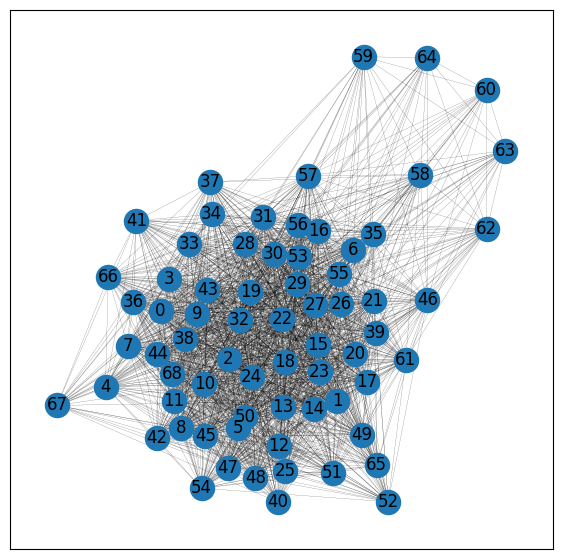

In [7]:
# Visualize
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(G, color):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=True, width=0.1)
    plt.show()

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color='red')

C:\Users\jackd\AppData\Local\Temp\ipykernel_25844\2067012154.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


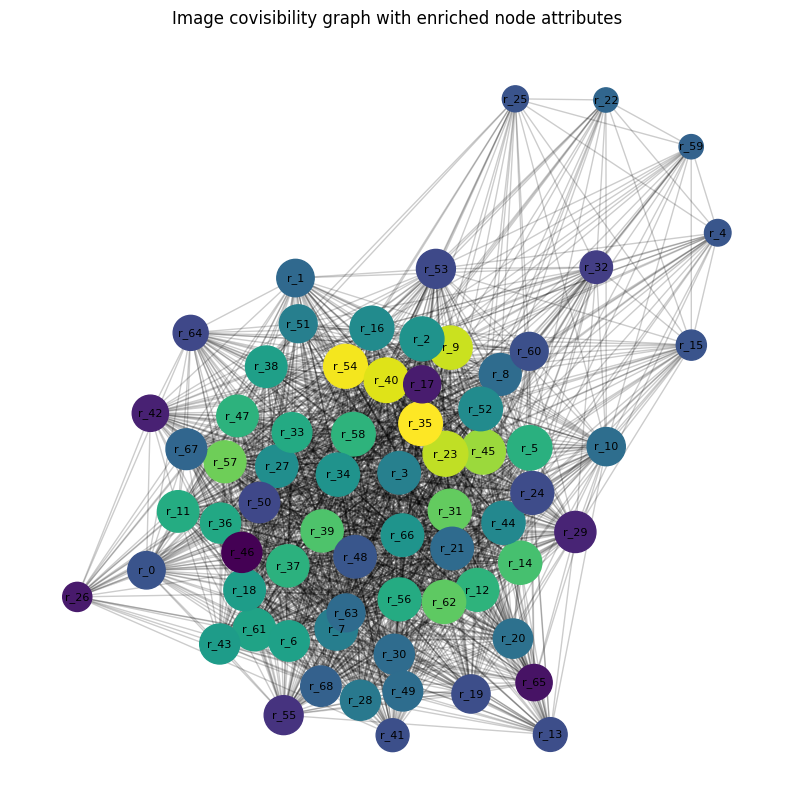

In [8]:
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np
import pathlib

# Convert the PyG graph to NetworkX so we can attach rich attributes per node.
G = to_networkx(data, to_undirected=True)

node_labels = {}
node_obs = {}
for image in reconstruction.images.values():
    idx = id_to_idx[image.image_id]
    node_labels[idx] = pathlib.Path(image.name).stem
    node_obs[idx] = sum(point.has_point3D() for point in image.points2D)

degrees = np.array([G.degree(n) for n in G.nodes()])
obs_values = np.array([node_obs[n] for n in G.nodes()])
if obs_values.size == 0:
    norm = colors.Normalize(vmin=0, vmax=1)
else:
    norm = colors.Normalize(vmin=obs_values.min(), vmax=obs_values.max())
cmap = cm.get_cmap("viridis")
node_colors = [cmap(norm(node_obs[n])) for n in G.nodes()]
node_sizes = 20 + 15 * degrees

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 10))
nx.draw_networkx_edges(G, pos, alpha=0.2)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
# plt.colorbar(sm, fraction=0.046, pad=0.04, label="Number of 3D observations")
plt.title("Image covisibility graph with enriched node attributes")
plt.axis("off")
plt.show()

# Subset graphs

In [9]:
# Create two disjoint image subsets from the reconstruction
import utils.subset
team_a_ids, team_b_ids = utils.subset.sample_image_subsets(reconstruction)

In [10]:
team_a_ids

[1,
 2,
 6,
 9,
 11,
 13,
 14,
 16,
 17,
 20,
 24,
 25,
 26,
 30,
 31,
 32,
 36,
 37,
 38,
 40,
 42,
 46,
 47,
 48,
 51,
 54,
 57,
 58,
 59,
 61,
 68]

In [11]:
team_a_image_centers = [image.projection_center() for image in reconstruction.images.values() if image.image_id in team_a_ids]

In [12]:
# Compute edges within the subset
team_a_id_to_idx = {image_id: idx for idx, image_id in enumerate(team_a_ids)}

# Initialize our lists for the edges
src, dst = [], []
# For each image in set A...
for src_id in team_a_ids:
    # Get all connected images
    for dst_id in utils.subset.get_covisible_image_ids(reconstruction, src_id):
        # We want to make sure the 
        if dst_id in team_a_id_to_idx:
            src.append(team_a_id_to_idx[src_id])
            dst.append(team_a_id_to_idx[dst_id])
team_a_edge_index = torch.tensor([src, dst], dtype=torch.long)

In [13]:
team_a_id_to_idx

{1: 0,
 2: 1,
 6: 2,
 9: 3,
 11: 4,
 13: 5,
 14: 6,
 16: 7,
 17: 8,
 20: 9,
 24: 10,
 25: 11,
 26: 12,
 30: 13,
 31: 14,
 32: 15,
 36: 16,
 37: 17,
 38: 18,
 40: 19,
 42: 20,
 46: 21,
 47: 22,
 48: 23,
 51: 24,
 54: 25,
 57: 26,
 58: 27,
 59: 28,
 61: 29,
 68: 30}

In [14]:
team_a_edge_index

tensor([[ 0,  0,  0,  ..., 30, 30, 30],
        [ 1,  2,  3,  ..., 27, 28, 29]])

In [15]:
from torch_geometric.data import Data

# Create the Data object
x = torch.tensor(team_a_image_centers, dtype=torch.float)
data = Data(x=x, edge_index=team_a_edge_index)
print(data)

Data(x=[31, 3], edge_index=[2, 834])


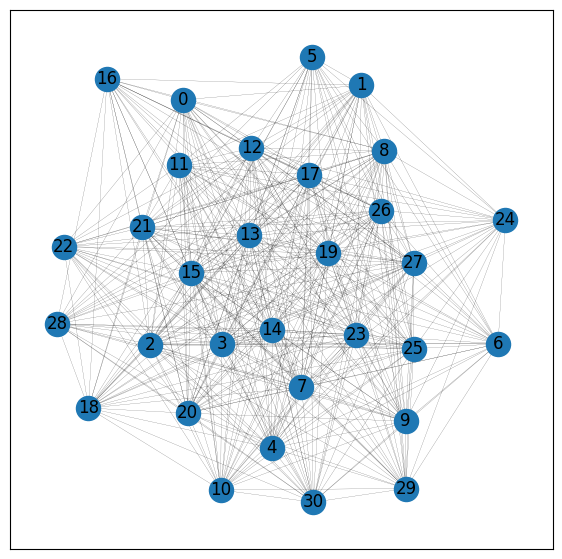

In [16]:
G = to_networkx(data, to_undirected=True)
visualize_graph(G, color='red')

In [17]:
for key in reconstruction.images.keys():
    print(key)

57
9
33
42
2
66
68
4
63
16
34
6
25
52
58
26
69
5
64
53
40
49
24
15
44
45
43
17
54
32
37
11
30
31
48
56
65
1
46
23
36
59
41
29
28
61
3
67
14
13
60
12
7
10
51
50
19
47
27
22
55
20
8
35
18
62
38
21
39


In [18]:
import utils.subset
utils.subset.reconstruction_to_pyg_data(reconstruction)

Data(x=[69, 3], edge_index=[2, 3686])

In [24]:
# This should FAIL due to failing an assertion! We are giving it a made up image_id! (123456)
utils.subset.reconstruction_to_pyg_data(reconstruction, [1, 2, 3, 4, 123456])

AssertionError: 

In [3]:
reconstruction.images.keys()

NameError: name 'reconstruction' is not defined

In [2]:
help(reconstruction.images.keys())

NameError: name 'reconstruction' is not defined